In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print("Saari libraries load ho gayi! ✅")

Matplotlib is building the font cache; this may take a moment.


Saari libraries load ho gayi! ✅


In [2]:
# Dataset load karo
df = pd.read_csv("../data/heart.csv")

# Pehli 5 rows dikhao
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Data ka size
print("Data ka size:", df.shape)

# Column ki information
print("\nData Information:")
df.info()

# Missing values check karo
print("\nMissing Values:")
print(df.isnull().sum())

# Basic statistics
print("\nStatistics:")
display(df.describe())

Data ka size: (918, 12)

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR            

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
# Cholesterol me 0 values ko median se replace karo
df["Cholesterol"] = df.groupby("HeartDisease")["Cholesterol"].transform(
    lambda x: x.replace(0, x.median())
)

print("✅ Data cleaning complete!")

✅ Data cleaning complete!


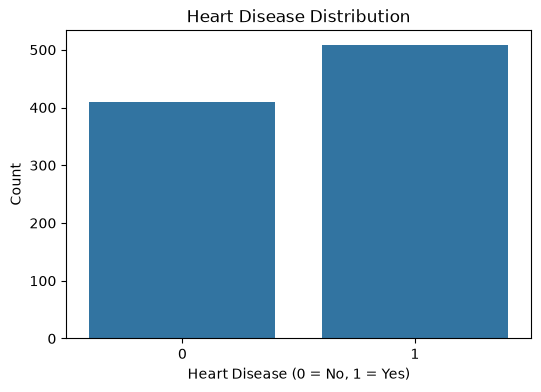

In [5]:
# Results folder banana (agar pehle se nahi hai)
os.makedirs("../results", exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(x="HeartDisease", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.savefig("../results/heart_disease_distribution.png")

plt.show()

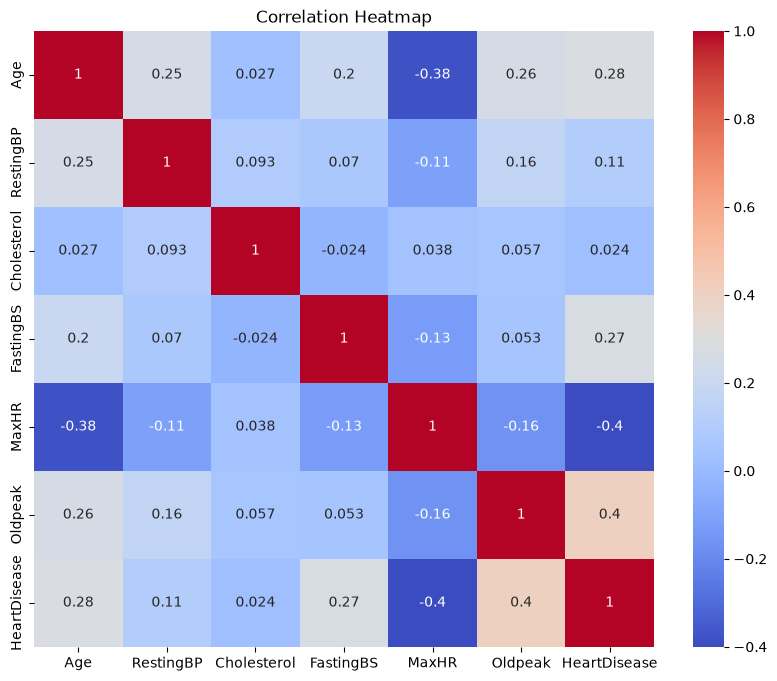

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../results/correlation_heatmap.png")

plt.show()

In [7]:
# Categorical columns
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

# Numerical columns
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

# Features aur Target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

print("✅ Features ready!")

✅ Features ready!


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (734, 11)
Testing : (184, 11)


In [9]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("✅ Model Training Complete!")

✅ Model Training Complete!


In [10]:
# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8750
Accuracy Percentage: 87.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        77
           1       0.90      0.89      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



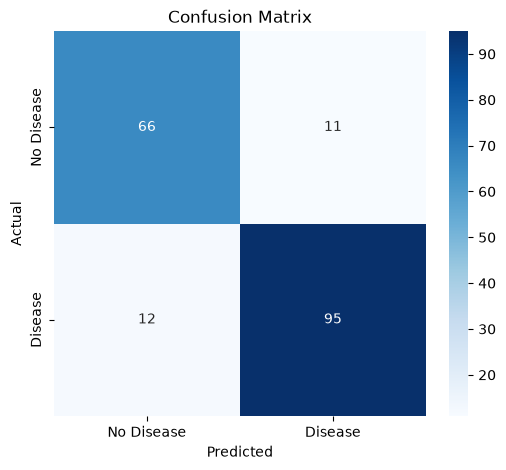

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("../results/confusion_matrix.png")

plt.show()

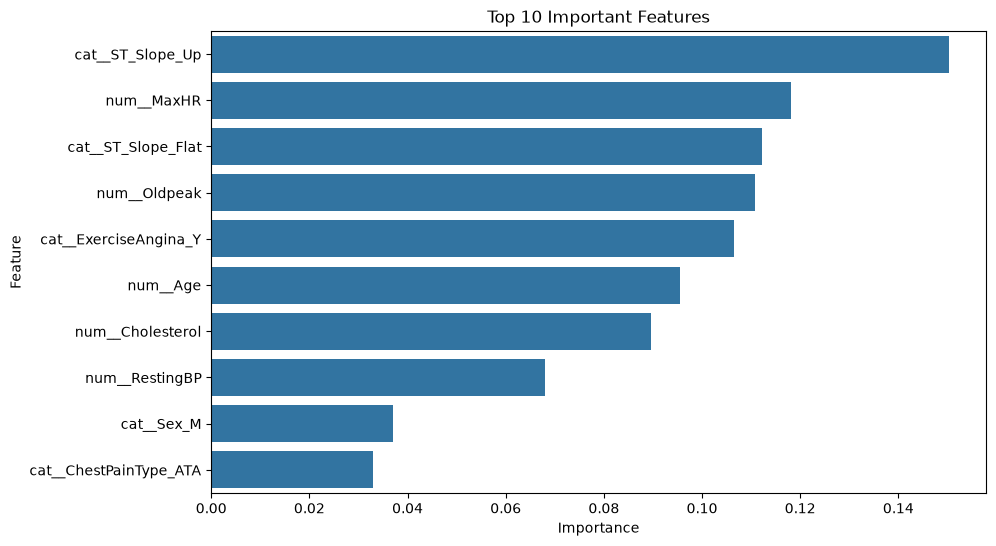

,Feature,Importance
14,cat__ST_Slope_Up,0.150381
4,num__MaxHR,0.118089
13,cat__ST_Slope_Flat,0.112131
5,num__Oldpeak,0.110877
12,cat__ExerciseAngina_Y,0.106588
0,num__Age,0.095445
2,num__Cholesterol,0.089607
1,num__RestingBP,0.068005
6,cat__Sex_M,0.037024
7,cat__ChestPainType_ATA,0.032992


In [12]:
# Random Forest Feature Importance

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("../results/feature_importance.png")

plt.show()

importance_df.head(10)

In [13]:
os.makedirs("../model", exist_ok=True)

joblib.dump(model, "../model/random_forest_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [14]:
loaded_model = joblib.load("../model/random_forest_model.pkl")

sample_prediction = loaded_model.predict(X_test.iloc[:5])

print("Predictions:", sample_prediction)
print("Actual:", y_test.iloc[:5].values)

Predictions: [0 1 1 1 0]
Actual: [0 1 1 1 0]
